# Loyalty × word-of-mouth — обробка результатів BehaviorSpace

Читає вивід шести експериментів (`e1`, `e2`, `e2b`, `e3`, `s1`, `s2`) з
`experiments/new-1/<experiment>/table.csv` і відповідає на три головні
питання дослідницької програми:

1. **Amplification (E1)** — чи підсилює розмова `program-lift`, і наскільки.
2. **Persistence (E2, E2b)** — чи тримає розмова звичку вище baseline довше
   після скасування програми, чи навпаки пришвidshує обвал.
3. **Substitution (E3)** — чи є програма і розмова замінниками чи
   доповнювачами в утриманні.

Плюс дві перевірки чутливості: **S1** (мережа) і **S2** (crowding out).

Джерело даних — файли `table.csv` (стандартний "table"-експорт
BehaviorSpace: один рядок на запуск, або на запуск×тік для E2b, з
іменованими колонками). Файли `spreadsheet.csv`, `stats.csv` і `lists.csv`
у цьому ноутбуці не використовуються — `table.csv` вже містить усе потрібне
в охайному (tidy) вигляді, і саме цей формат найнадійніше парситься.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

try:
    import statsmodels.api as sm
    from statsmodels.formula.api import ols
    HAVE_STATSMODELS = True
except ImportError:
    HAVE_STATSMODELS = False
    warnings.warn("statsmodels не встановлено — двофакторний ANOVA у E3 "
                   "буде замінено на ручний контраст взаємодії з bootstrap CI.")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# --------------------------------------------------------------------
# CONFIG — edit these two lines if your layout differs
# --------------------------------------------------------------------
BASE_DIR = Path("experiments/new-1")
EXPERIMENTS = ["e1", "e2", "e2b", "e3", "s1", "s2"]

CI_LEVEL = 0.95          # confidence level used throughout
SAVE_FIGS = False        # set True to also write PNGs alongside the notebook
FIG_DIR = Path("figures")
if SAVE_FIGS:
    FIG_DIR.mkdir(exist_ok=True)

# NetLogo schedule constants (initialize-constants in the model code).
# Only used to draw phase-boundary reference lines in the E2b trajectory
# plots — if these constants ever change in the model, update them here too.
SCHEDULE = dict(baseline=50, reward=40, pause=20, final=100)
SALIENCE_THRESHOLD = 0.60   # crowding-out sign switch, used as a reference line in S2

assert BASE_DIR.exists(), (
    f"'{BASE_DIR}' not found. Run this notebook from the directory that "
    f"contains 'experiments/new-1/', or edit BASE_DIR above."
)

## Завантаження

`table.csv` починається з преамбули змінної довжини (назва моделі,
назва експерименту, `min/max-pxcor/pycor`) перед фактичним заголовком
колонок, що завжди починається з `[run number]`. Замість жорстко
зашитого числа рядків для пропуску, `read_bs_table` шукає цей рядок
автоматично — це стійкіше до дрібних відмінностей у преамбулі між
версіями NetLogo.

Назви колонок далі очищуються у `snake_case`
(`brand-share "baseline"` → `brand_share_baseline`,
`program-on?` → `program_on`, `[step]` → `step`), а типи приводяться:
`program_on`/`wom_on` → `bool`, `contagion_rule`/`network_topology`/
`current_phase` → `category`, решта нечислових колонок — до числа, де
це можливо.

In [2]:
def read_bs_table(path: Path) -> pd.DataFrame:
    """Read a NetLogo BehaviorSpace 'table' CSV export, skipping the
    variable-length metadata preamble by locating the header row."""
    with open(path, encoding="utf-8") as f:
        lines = f.readlines()
    header_idx = next(
        (i for i, line in enumerate(lines)
         if line.lstrip().startswith('[run number]')
         or line.lstrip().startswith('"[run number]"')),
        None,
    )
    if header_idx is None:
        raise ValueError(
            f"Could not find a '[run number]' header row in {path}. "
            f"Is this really a BehaviorSpace 'table' export?"
        )
    return pd.read_csv(path, skiprows=header_idx)


def snake(name: str) -> str:
    """'brand-share \"baseline\"' -> 'brand_share_baseline';
    'program-on?' -> 'program_on'; '[step]' -> 'step'."""
    s = str(name).strip()
    s = s.replace("[", "").replace("]", "").replace('"', " ")
    s = re.sub(r"[^0-9a-zA-Z]+", "_", s)
    return re.sub(r"_+", "_", s).strip("_").lower()


BOOL_COLS = ["program_on", "wom_on"]
CATEGORY_COLS = ["contagion_rule", "network_topology", "current_phase"]


def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [snake(c) for c in df.columns]
    return df


def coerce_types(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for c in BOOL_COLS:
        if c in df.columns:
            df[c] = (df[c].astype(str).str.strip().str.strip('"').str.lower()
                        .map({"true": True, "false": False}))
    for c in CATEGORY_COLS:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip().str.strip('"').astype("category")
    # anything left as text that is actually numeric (e.g. a quoted number) -> numeric
    handled = set(BOOL_COLS) | set(CATEGORY_COLS)
    for c in df.columns:
        if c in handled:
            continue
        if df[c].dtype == object:
            converted = pd.to_numeric(
                df[c].astype(str).str.strip().str.strip('"'), errors="coerce"
            )
            if converted.notna().mean() > 0.99:
                df[c] = converted
    return df


def qa_report(df: pd.DataFrame, name: str) -> None:
    """Cheap sanity checks — warn, don't crash, so one odd column doesn't
    block the rest of the notebook."""
    n_dupe_runs = 0
    if "run_number" in df.columns and "step" not in df.columns:
        n_dupe_runs = df["run_number"].duplicated().sum()
    problems = []
    if n_dupe_runs:
        problems.append(f"{n_dupe_runs} duplicated run_number values")
    for c in BOOL_COLS:
        if c in df.columns and df[c].isna().any():
            problems.append(f"'{c}' has {df[c].isna().sum()} unparsed values")
    all_na_cols = [c for c in df.columns if df[c].isna().all()]
    if all_na_cols:
        problems.append(f"fully-empty columns: {all_na_cols}")
    if problems:
        print(f"  [QA WARNING] {name}: " + "; ".join(problems))


def load_experiment(key: str, filename: str = "table.csv") -> pd.DataFrame:
    path = BASE_DIR / key / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Expected '{path}' — check that BehaviorSpace exported "
            f"'{filename}' for experiment '{key}' into that folder."
        )
    df = coerce_types(clean_columns(read_bs_table(path)))
    qa_report(df, key)
    return df


data = {key: load_experiment(key) for key in EXPERIMENTS}
for key, df in data.items():
    n_runs = df["run_number"].nunique()
    print(f"{key:4s}  rows={len(df):5d}  runs={n_runs:4d}  cols={df.shape[1]}")

e1    rows=  960  runs= 960  cols=34
e2    rows= 1440  runs=1440  cols=34
e2b   rows= 5020  runs=  20  cols=21
e3    rows=  480  runs= 480  cols=34
s1    rows=  720  runs= 720  cols=34
s2    rows=  200  runs= 200  cols=34


## Спільні інструменти аналізу

`summarize` рахує середнє, довірчий інтервал (t-розподіл) та розмір
вибірки за групами. `cohens_d` і `rank_biserial` — розміри ефекту для
порівняння двох груп (t-тест і Mann–Whitney відповідно), оскільки p-value
саме по собі не каже, наскільки великий ефект.

In [3]:
def summarize(df: pd.DataFrame, group_cols, value_col: str, ci: float = CI_LEVEL) -> pd.DataFrame:
    g = df.groupby(group_cols, observed=True)[value_col]
    out = g.agg(n="count", mean="mean", std="std").reset_index()
    out["sem"] = out["std"] / np.sqrt(out["n"])
    tcrit = stats.t.ppf(0.5 + ci / 2, (out["n"] - 1).clip(lower=1))
    out["ci_lo"] = out["mean"] - tcrit * out["sem"]
    out["ci_hi"] = out["mean"] + tcrit * out["sem"]
    return out


def cohens_d(a, b) -> float:
    a, b = np.asarray(a, float), np.asarray(b, float)
    n1, n2 = len(a), len(b)
    pooled_sd = np.sqrt(((n1 - 1) * a.var(ddof=1) + (n2 - 1) * b.var(ddof=1)) / (n1 + n2 - 2))
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else np.nan


def rank_biserial(a, b) -> float:
    """Effect size that accompanies the Mann-Whitney U test, in [-1, 1]."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    u, _ = stats.mannwhitneyu(a, b, alternative="two-sided")
    return 1 - (2 * u) / (len(a) * len(b))


def compare_two_groups(df: pd.DataFrame, group_col: str, value_col: str,
                        group_true_label="on", group_false_label="off") -> dict:
    """Bundle of paired diagnostics for a boolean-grouped comparison."""
    a = df.loc[df[group_col] == True, value_col].dropna()
    b = df.loc[df[group_col] == False, value_col].dropna()
    u_stat, p_mwu = stats.mannwhitneyu(a, b, alternative="two-sided")
    t_stat, p_t = stats.ttest_ind(a, b, equal_var=False)
    return dict(
        metric=value_col,
        mean_on=a.mean(), mean_off=b.mean(), diff=a.mean() - b.mean(),
        cohens_d=cohens_d(a, b), rank_biserial=rank_biserial(a, b),
        p_mannwhitney=p_mwu, p_welch=p_t, n_on=len(a), n_off=len(b),
    )


def bar_with_ci(ax, summary_df, x_col, y="mean", lo="ci_lo", hi="ci_hi",
                 labels=None, colors=None, title=None):
    x = np.arange(len(summary_df))
    means = summary_df[y].to_numpy()
    err = np.vstack([means - summary_df[lo].to_numpy(), summary_df[hi].to_numpy() - means])
    bar_colors = colors if colors is not None else None
    ax.bar(x, means, yerr=err, capsize=4, color=bar_colors, edgecolor="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels if labels is not None else summary_df[x_col].astype(str), rotation=0)
    if title:
        ax.set_title(title)
    ax.axhline(0, color="black", linewidth=0.8)
    return ax


def maybe_save(fig, name):
    if SAVE_FIGS:
        fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")

## E1 — Amplification

Питання: при увімкненій програмі, чи розмова піднімає `program_lift`
(частка вибору бренду під час кампанії мінус baseline), і наскільки?
Порівняння між запусками — `wom_on` тут єдиний бінарний фактор інтересу,
решта (`contagion_rule`, `adoption_threshold`, `talk_strength`,
`rewiring_probability`) — вторинні виміри чутливості.

Amplification — program_lift, розмова увімк. проти вимк.:
  metric           program_lift
  mean_on          0.5185555598958334
  mean_off         0.42614883463541664
  diff             0.09240672526041671
  cohens_d         3.2306638544814335
  rank_biserial    -0.997751736111111
  p_mannwhitney    9.848754789380592e-158
  p_welch          2.2824536164285916e-196
  n_on             480
  n_off            480


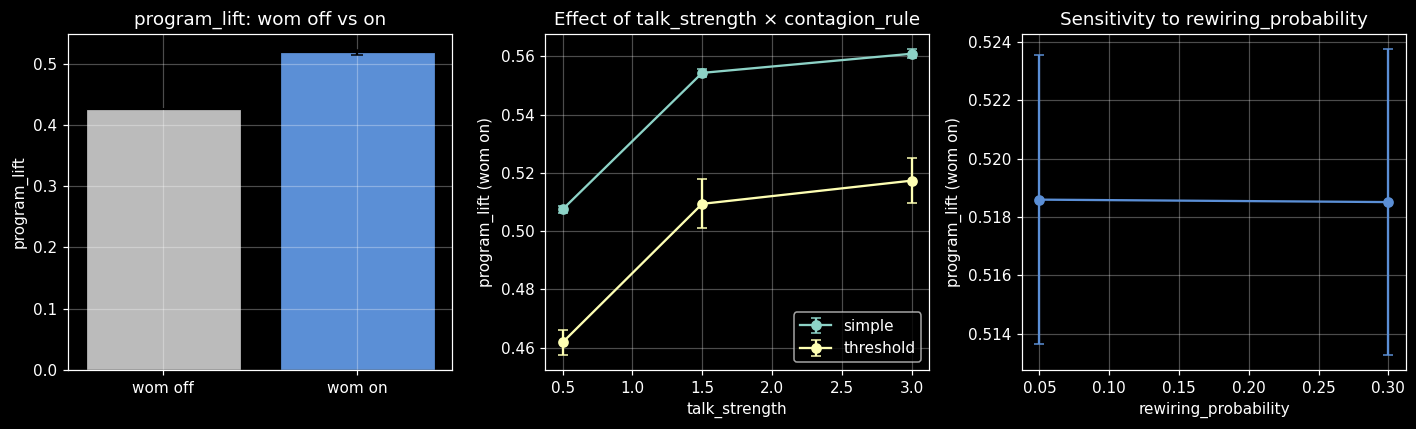

In [4]:
e1 = data["e1"]

e1_overall = compare_two_groups(e1, "wom_on", "program_lift")
print("Amplification — program_lift, розмова увімк. проти вимк.:")
for k, v in e1_overall.items():
    print(f"  {k:16s} {v}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

s = summarize(e1, ["wom_on"], "program_lift")
bar_with_ci(axes[0], s, "wom_on", labels=["wom off", "wom on"],
            colors=["#BBBBBB", "#5B8FD6"], title="program_lift: wom off vs on")
axes[0].set_ylabel("program_lift")

s2 = summarize(e1[e1.wom_on], ["contagion_rule", "talk_strength"], "program_lift")
for rule, g in s2.groupby("contagion_rule", observed=True):
    axes[1].errorbar(g["talk_strength"], g["mean"],
                      yerr=[g["mean"] - g["ci_lo"], g["ci_hi"] - g["mean"]],
                      marker="o", capsize=3, label=rule)
axes[1].set_xlabel("talk_strength")
axes[1].set_ylabel("program_lift (wom on)")
axes[1].set_title("Effect of talk_strength × contagion_rule")
axes[1].legend()

s3 = summarize(e1[e1.wom_on], ["rewiring_probability"], "program_lift")
axes[2].errorbar(s3["rewiring_probability"], s3["mean"],
                  yerr=[s3["mean"] - s3["ci_lo"], s3["ci_hi"] - s3["mean"]],
                  marker="o", capsize=3, color="#5B8FD6")
axes[2].set_xlabel("rewiring_probability")
axes[2].set_ylabel("program_lift (wom on)")
axes[2].set_title("Sensitivity to rewiring_probability")

fig.tight_layout()
maybe_save(fig, "e1_amplification")
plt.show()

## E2 — Persistence

Питання: після скасування програми, чи звичка тримається вище baseline
довше при увімкненій розмові — чи розмова, навпаки, розносить
розчарування і пришвидшує обвал? Рівень (`persistence_index`) і
тривалість (`ticks_above_baseline`, `ticks_to_collapse`) — це різні
речі, тому дивимось на обидва: розмова може підняти середній
післяпрограмний рівень і водночас скоротити час утримання.

Persistence — wom on проти off, за трьома метриками:
                       mean_off    mean_on      diff  cohens_d  p_mannwhitney
metric                                                                       
persistence_index     -0.035844  -0.096504 -0.060659 -3.330984  2.698814e-236
ticks_above_baseline  25.880556  16.906944 -8.973611 -7.669724  1.913514e-242
ticks_to_collapse     26.880556  17.906944 -8.973611 -7.669724  1.913514e-242


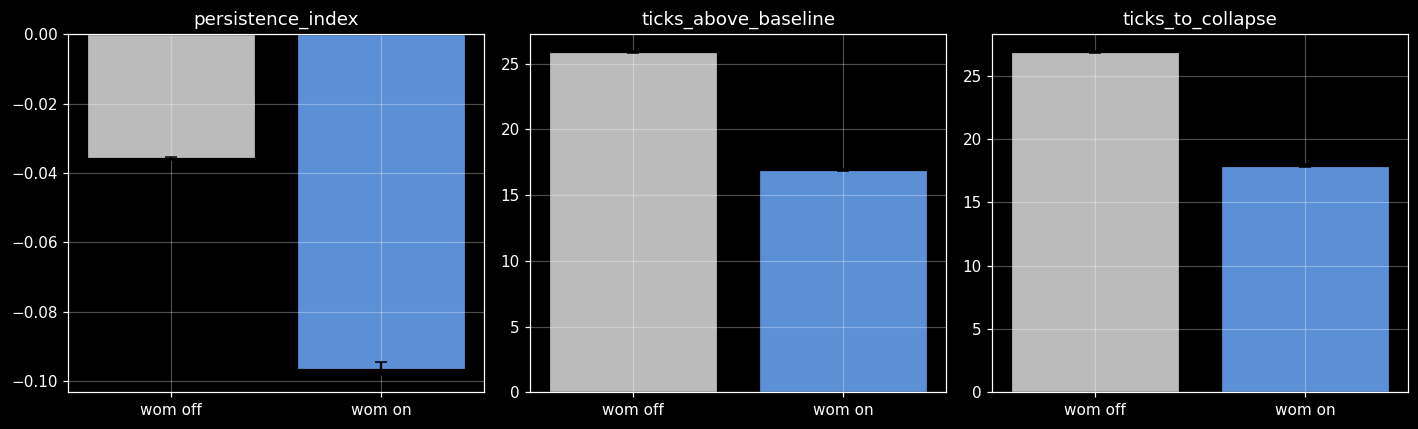

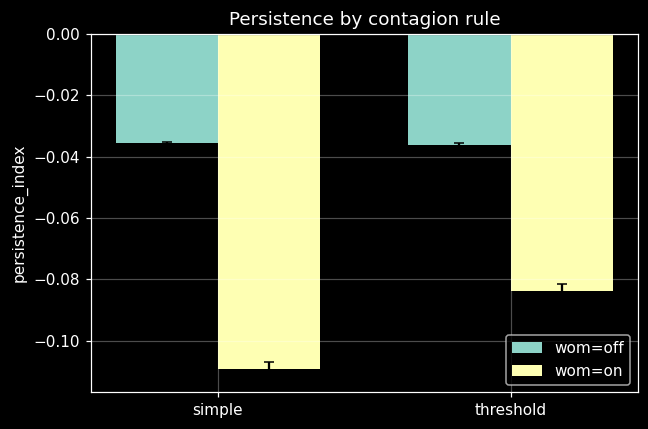

In [5]:
e2 = data["e2"]

persistence_metrics = ["persistence_index", "ticks_above_baseline", "ticks_to_collapse"]
e2_results = pd.DataFrame([compare_two_groups(e2, "wom_on", m) for m in persistence_metrics])
print("Persistence — wom on проти off, за трьома метриками:")
print(e2_results.set_index("metric")[["mean_off", "mean_on", "diff", "cohens_d", "p_mannwhitney"]])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ["#BBBBBB", "#5B8FD6"]
for ax, m in zip(axes, persistence_metrics):
    s = summarize(e2, ["wom_on"], m)
    bar_with_ci(ax, s, "wom_on", labels=["wom off", "wom on"], colors=colors, title=m)
fig.tight_layout()
maybe_save(fig, "e2_persistence_overview")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
s = summarize(e2, ["wom_on", "contagion_rule"], "persistence_index")
width = 0.35
rules = s["contagion_rule"].cat.categories if hasattr(s["contagion_rule"], "cat") else s["contagion_rule"].unique()
for i, wom in enumerate([False, True]):
    sub = s[s.wom_on == wom].set_index("contagion_rule")
    xs = np.arange(len(rules)) + (i - 0.5) * width
    ax.bar(xs, sub.loc[rules, "mean"], width=width,
           yerr=[sub.loc[rules, "mean"] - sub.loc[rules, "ci_lo"],
                 sub.loc[rules, "ci_hi"] - sub.loc[rules, "mean"]],
           label=f"wom={'on' if wom else 'off'}", capsize=3)
ax.set_xticks(range(len(rules)))
ax.set_xticklabels(rules)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("persistence_index")
ax.set_title("Persistence by contagion rule")
ax.legend()
fig.tight_layout()
maybe_save(fig, "e2_persistence_by_rule")
plt.show()

## E2b — траєкторії (звідки береться розбіжність рівня й тривалості)

E2b записує метрики на кожному тіку (`runMetricsEveryStep`), тому тут
можна побачити ХІД обвалу, а не лише його кінцевий стан. Вертикальні
лінії — межі фаз, обчислені за тими самими константами розкладу, що і в
коді моделі (`baseline`, `reward`, `pause`, `final` цикли).

Phase boundaries (ticks): {'baseline_end': 50, 'program_end': 150, 'end': 250}


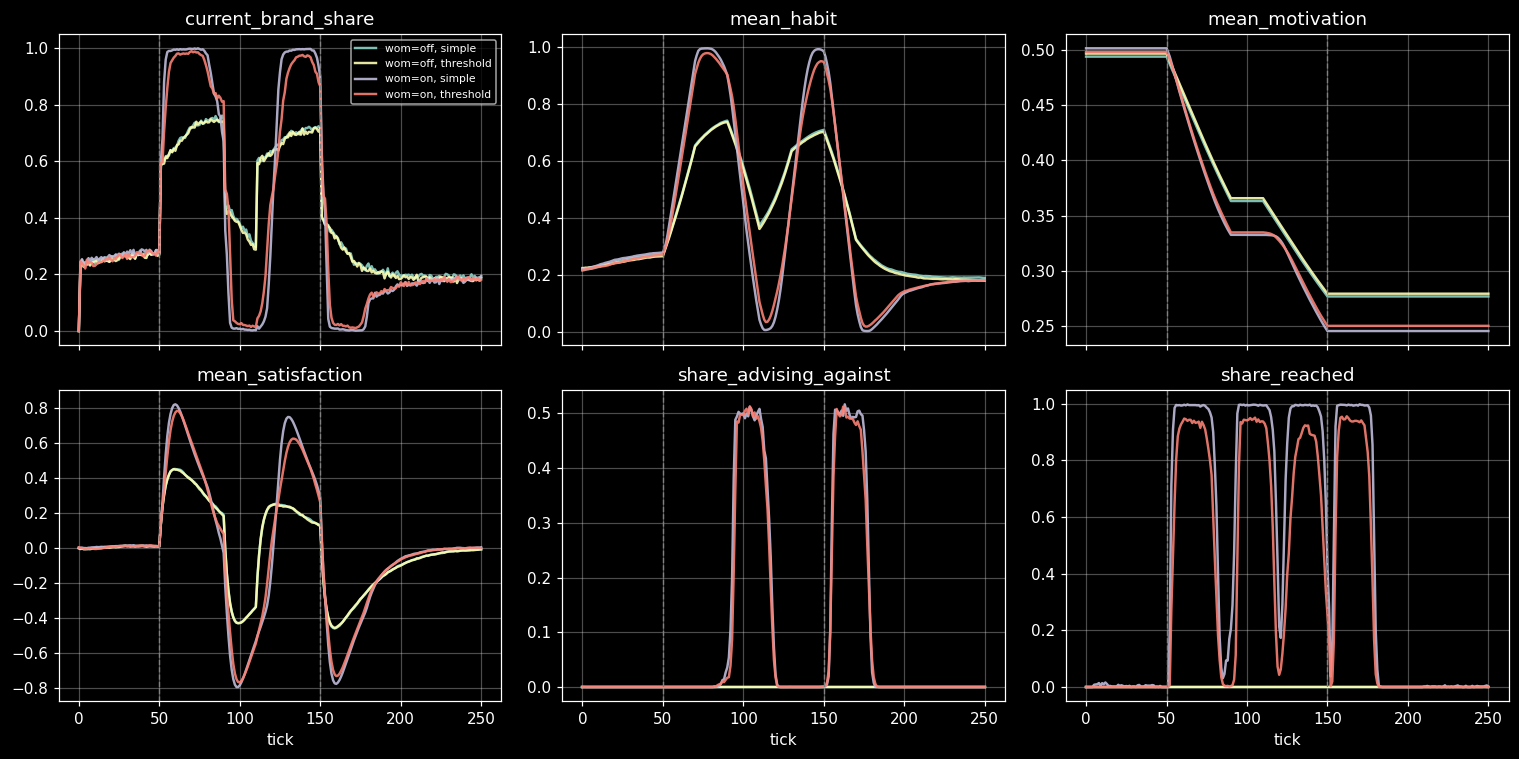

In [6]:
def phase_boundaries(reward_cycles: int, sched=SCHEDULE) -> dict:
    """Reproduces the schedule from the model's `program-window` /
    `experiment-end` reporters: baseline | [campaign+pause] x (cycles-1)
    | campaign | final."""
    prog_win = (reward_cycles - 1) * (sched["reward"] + sched["pause"]) + sched["reward"]
    baseline_end = sched["baseline"]
    program_end = baseline_end + prog_win
    end = program_end + sched["final"]
    return dict(baseline_end=baseline_end, program_end=program_end, end=end)


e2b = data["e2b"]
cycles = int(e2b["reward_cycles"].iloc[0])
bnd = phase_boundaries(cycles)
print("Phase boundaries (ticks):", bnd)

traj_metrics = ["current_brand_share", "mean_habit", "mean_motivation",
                "mean_satisfaction", "share_advising_against", "share_reached"]
traj = (e2b.groupby(["wom_on", "contagion_rule", "step"], observed=True)[traj_metrics]
            .mean().reset_index())

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
for ax, metric in zip(axes.flat, traj_metrics):
    for (wom, rule), g in traj.groupby(["wom_on", "contagion_rule"], observed=True):
        ax.plot(g["step"], g[metric], label=f"wom={'on' if wom else 'off'}, {rule}",
                linewidth=1.6, alpha=0.9)
    for x in (bnd["baseline_end"], bnd["program_end"]):
        ax.axvline(x, color="gray", linestyle="--", linewidth=0.9)
    ax.set_title(metric)
axes[0, 0].legend(fontsize=7, loc="best")
for ax in axes[-1]:
    ax.set_xlabel("tick")
fig.tight_layout()
maybe_save(fig, "e2b_trajectories")
plt.show()

## E3 — Substitution (факторіал program × wom)

Повний факторіал `program_on × wom_on`. Взаємодія — це
`(on,on) − (on,off) − (off,on) + (off,off)`: від'ємне значення означає,
що канали є замінниками (сумарний ефект менший за суму окремих),
додатне — доповнювачами.

                    off_off    off_on    on_off     on_on  interaction
metric                                                                
program_lift       0.019703  0.019387  0.425468  0.548562     0.123410
persistence_index  0.020842  0.019949 -0.036003 -0.115921    -0.079026
retention_ratio    1.004180  1.002009  0.328430  0.181262    -0.144997

Двофакторний ANOVA для persistence_index:
                           sum_sq     df             F         PR(>F)
C(program_on)            1.114183    1.0  27074.565632   0.000000e+00
C(wom_on)                0.195912    1.0   4760.652963  5.237972e-250
C(program_on):C(wom_on)  0.187351    1.0   4552.615444  8.130868e-246
Residual                 0.019589  476.0           NaN            NaN


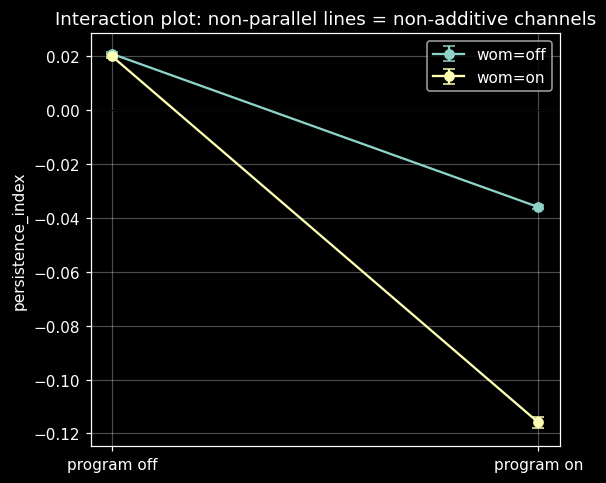

In [7]:
e3 = data["e3"]

interaction_metrics = ["program_lift", "persistence_index", "retention_ratio"]
rows = []
for m in interaction_metrics:
    tab = e3.groupby(["program_on", "wom_on"], observed=True)[m].mean().unstack()
    interaction = tab.loc[True, True] - tab.loc[True, False] - tab.loc[False, True] + tab.loc[False, False]
    rows.append(dict(metric=m, off_off=tab.loc[False, False], off_on=tab.loc[False, True],
                      on_off=tab.loc[True, False], on_on=tab.loc[True, True],
                      interaction=interaction))
e3_summary = pd.DataFrame(rows).set_index("metric")
print(e3_summary)

if HAVE_STATSMODELS:
    print("\nДвофакторний ANOVA для persistence_index:")
    model = ols("persistence_index ~ C(program_on) * C(wom_on)", data=e3).fit()
    print(sm.stats.anova_lm(model, typ=2))
else:
    rng = np.random.default_rng(0)
    boot = []
    for _ in range(2000):
        s = e3.sample(frac=1, replace=True, random_state=rng.integers(0, 2**31 - 1))
        tab = s.groupby(["program_on", "wom_on"], observed=True)["persistence_index"].mean().unstack()
        boot.append(tab.loc[True, True] - tab.loc[True, False] - tab.loc[False, True] + tab.loc[False, False])
    lo, hi = np.percentile(boot, [2.5, 97.5])
    print(f"\nBootstrap 95% CI on the persistence_index interaction: [{lo:.4f}, {hi:.4f}]")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
s = summarize(e3, ["program_on", "wom_on"], "persistence_index")
for wom in [False, True]:
    sub = s[s.wom_on == wom].sort_values("program_on")
    ax.errorbar(sub["program_on"].astype(int), sub["mean"],
                yerr=[sub["mean"] - sub["ci_lo"], sub["ci_hi"] - sub["mean"]],
                marker="o", capsize=4, label=f"wom={'on' if wom else 'off'}")
ax.set_xticks([0, 1])
ax.set_xticklabels(["program off", "program on"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("persistence_index")
ax.set_title("Interaction plot: non-parallel lines = non-additive channels")
ax.legend()
fig.tight_layout()
maybe_save(fig, "e3_interaction")
plt.show()

## S1 — чутливість до мережі

Наскільки `program_lift` залежить від топології, `rewiring_probability`
та `talk_activity`. Це перевірка на конфаунд: чи результати E1–E3
залежать від конкретної структури мережі, чи ні.

/var/folders/p_/yh52zt9953v7py3ry5z3kms00000gn/T/ipykernel_75099/4087727970.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = s1.pivot_table(index="network_topology", columns="rewiring_probability",


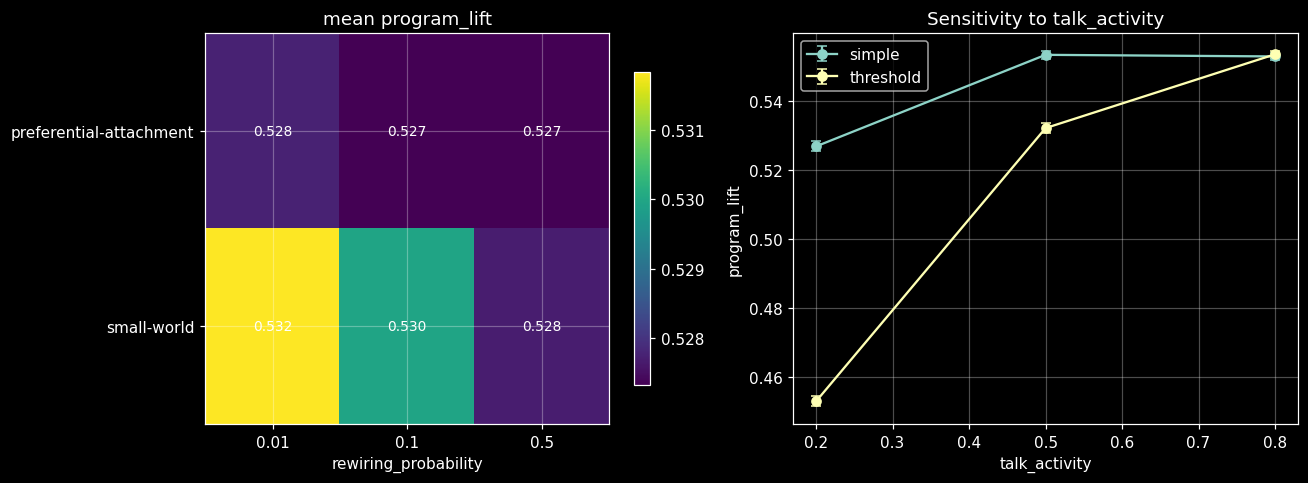

Range of mean program_lift across topology x rewiring_probability: 0.5273 .. 0.5318 (a narrow range here means the result is not a network-topology artifact)


In [8]:
s1 = data["s1"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

piv = s1.pivot_table(index="network_topology", columns="rewiring_probability",
                      values="program_lift", aggfunc="mean")
im = axes[0].imshow(piv.values, aspect="auto", cmap="viridis")
axes[0].set_xticks(range(len(piv.columns)))
axes[0].set_xticklabels(piv.columns)
axes[0].set_yticks(range(len(piv.index)))
axes[0].set_yticklabels(piv.index)
axes[0].set_xlabel("rewiring_probability")
axes[0].set_title("mean program_lift")
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        axes[0].text(j, i, f"{piv.values[i, j]:.3f}", ha="center", va="center",
                      color="white", fontsize=9)
fig.colorbar(im, ax=axes[0], shrink=0.8)

s = summarize(s1, ["contagion_rule", "talk_activity"], "program_lift")
for rule, g in s.groupby("contagion_rule", observed=True):
    axes[1].errorbar(g["talk_activity"], g["mean"],
                      yerr=[g["mean"] - g["ci_lo"], g["ci_hi"] - g["mean"]],
                      marker="o", capsize=3, label=rule)
axes[1].set_xlabel("talk_activity")
axes[1].set_ylabel("program_lift")
axes[1].set_title("Sensitivity to talk_activity")
axes[1].legend()

fig.tight_layout()
maybe_save(fig, "s1_network_sensitivity")
plt.show()

print("Range of mean program_lift across topology x rewiring_probability:",
      f"{piv.values.min():.4f} .. {piv.values.max():.4f}",
      "(a narrow range here means the result is not a network-topology artifact)")

## S2 — crowding out

Свіп `reward_salience` через поріг `SALIENCE_THRESHOLD = 0.60` (константа
моделі, не параметр UI). Знак `motivation_loss` мав би перемикатись саме
на цьому порозі.

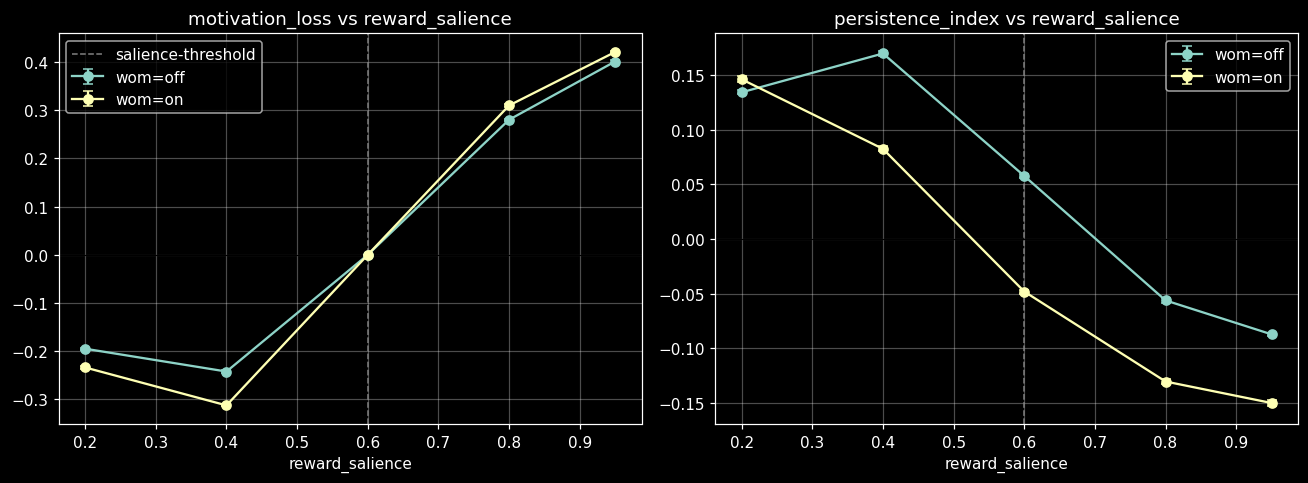

In [9]:
s2 = data["s2"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for wom in [False, True]:
    sub = s2[s2.wom_on == wom]
    s = summarize(sub, ["reward_salience"], "motivation_loss")
    axes[0].errorbar(s["reward_salience"], s["mean"],
                      yerr=[s["mean"] - s["ci_lo"], s["ci_hi"] - s["mean"]],
                      marker="o", capsize=3, label=f"wom={'on' if wom else 'off'}")

    s2m = summarize(sub, ["reward_salience"], "persistence_index")
    axes[1].errorbar(s2m["reward_salience"], s2m["mean"],
                      yerr=[s2m["mean"] - s2m["ci_lo"], s2m["ci_hi"] - s2m["mean"]],
                      marker="o", capsize=3, label=f"wom={'on' if wom else 'off'}")

for ax, title in zip(axes, ["motivation_loss vs reward_salience", "persistence_index vs reward_salience"]):
    ax.axvline(SALIENCE_THRESHOLD, color="gray", linestyle="--", linewidth=1,
               label="salience-threshold" if ax is axes[0] else None)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("reward_salience")
    ax.set_title(title)
    ax.legend()

fig.tight_layout()
maybe_save(fig, "s2_crowding_out")
plt.show()

## Підсумок

Зведена таблиця будується з обчислених вище статистик (не вписана вручну),
щоб вона завжди відповідала актуальним даним у `experiments/new-1`.

In [10]:
summary_rows = []

r = compare_two_groups(e1, "wom_on", "program_lift")
summary_rows.append(dict(
    question="1. Amplification",
    finding=f"program_lift {'вище' if r['diff'] > 0 else 'нижче'} на {r['diff']:.3f} при wom on",
    effect_size=f"Cohen's d = {r['cohens_d']:.2f}",
    p_value=f"p = {r['p_mannwhitney']:.2e} (Mann-Whitney)",
))

r = compare_two_groups(e2, "wom_on", "persistence_index")
r2 = compare_two_groups(e2, "wom_on", "ticks_above_baseline")
summary_rows.append(dict(
    question="2. Persistence — рівень",
    finding=f"persistence_index {'вище' if r['diff'] > 0 else 'нижче'} на {r['diff']:.3f} при wom on",
    effect_size=f"Cohen's d = {r['cohens_d']:.2f}",
    p_value=f"p = {r['p_mannwhitney']:.2e}",
))
summary_rows.append(dict(
    question="2. Persistence — тривалість",
    finding=f"ticks_above_baseline {'вище' if r2['diff'] > 0 else 'нижче'} на {r2['diff']:.1f} тіків при wom on",
    effect_size=f"Cohen's d = {r2['cohens_d']:.2f}",
    p_value=f"p = {r2['p_mannwhitney']:.2e}",
))

interaction = e3_summary.loc["persistence_index", "interaction"]
summary_rows.append(dict(
    question="3. Substitution",
    finding=("канали замінники (суб'адитивно)" if interaction < 0 else "канали доповнювачі (супрадитивно)")
             + f", взаємодія = {interaction:.3f}",
    effect_size="—",
    p_value=("statsmodels ANOVA вище" if HAVE_STATSMODELS else "bootstrap CI вище"),
))

summary = pd.DataFrame(summary_rows).set_index("question")
summary

,finding,effect_size,p_value
question,,,
1. Amplification,program_lift вище на 0.092 при wom on,Cohen's d = 3.23,p = 9.85e-158 (Mann-Whitney)
2. Persistence — рівень,persistence_index нижче на -0.061 при wom on,Cohen's d = -3.33,p = 2.70e-236
2. Persistence — тривалість,ticks_above_baseline нижче на -9.0 тіків при w...,Cohen's d = -7.67,p = 1.91e-242
3. Substitution,"канали замінники (суб'адитивно), взаємодія = -...",—,statsmodels ANOVA вище
